In [13]:
%matplotlib inline

import os
import sys
import copy

import matplotlib.pyplot as plt

sys.path.append('../../../')

%load_ext autoreload
%autoreload 2

from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.yolov11_pose.nn.tasks import PoseModel
from computer_vision.yolov11.data.utils import imread
from computer_vision.yolov11.data.augment import LetterBox # for preprocessing
from computer_vision.yolov11_pose.utils.nms import non_max_suppression # for post processing
from computer_vision.yolov11_pose.utils.ops import scale_boxes

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import cv2
import numpy as np
import torch

from computer_vision.yolov11_pose.utils import DEFAULT_CFG_DICT
from computer_vision.yolov11_pose.cfg import get_cfg

class PosePredictor:
    """
    This class specializes in pose estimation, handling keypoint detection alongside standard object detection capabilities
    """
    def __init__(self, cfg=DEFAULT_CFG_DICT, overrides=None):
        """
        Initialize PosePredictor for pose estimation
        Args:
            cfg (Any): Configuration for the predictor
            overrides (dict, optional): Configuration overrides that take precedence over cfg
        """
        self.args=get_cfg(cfg, overrides)
        self.save_dir=self.args.save_dir

        if self.args.conf is None: self.args.conf=0.25 
        
        

In [3]:
output_dirpath='D:/results/yolov11_pose/predict'
args=parser.parse_args(f'--save-dir {output_dirpath}'.split())

device=torch.device('cpu')

predictor=PosePredictor(overrides=args)

overrides  <class 'dict'>  cfg  <class 'dict'>


In [stream_inference](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/engine/predictor.py#L276)
- setup model
- setup input image

In [4]:
cfg='../yolo11-pose.yaml'
model=PoseModel(cfg=cfg,nc=1,verbose=True)
model.fuse(); # we need to call `fuse` so we can successfully load pretrained weight
checkpoint_file=os.path.join(output_dirpath, 'yolo11n_torch.pt')
assert os.path.isfile(checkpoint_file), f'{checkpoint_file} does not exist'
checkpoint=torch.load(checkpoint_file, weights_only=False)
try:
    model.load_state_dict(checkpoint['model'])
except RuntimeError as err:
    state_dict=copy.deepcopy(model.state_dict())
    for name, params in checkpoint['model'].items():
        name=name[len('model.'):] # each parameter name is model.model.xxx so we need to remove 1 model.
        
        if name not in state_dict or params.shape!=state_dict[name].shape:
            print(name, name in state_dict, (params.shape,state_dict[name].shape) if name in state_dict else None)
        else: state_dict[name]=params
    model.load_state_dict(state_dict)

In nn.tasks.DetectionModel.__init__ input 1 is not equal to nc in yaml 80->overwrite yaml by input
In nn.tasks.parse_model nc 1, act None, scales {'n': [0.5, 0.25, 1024], 's': [0.5, 0.5, 1024], 'm': [0.5, 1.0, 512], 'l': [1.0, 1.0, 512], 'x': [1.0, 1.5, 512]}
In nn.tasks.parse_model depth 1.0, width 1.0, kpt_shape [17, 3]
In nn.tasks.parse_model no model scale passed. Assuming scale=n.
In nn.tasks.parse_model depth 0.5, width 0.25, max_channels 1024

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  Conv                                         [3, 16, 3, 2]                 
  1                  -1  1      4672  Conv                                         [16, 32, 3, 2]                
  2                  -1  1      6640  C3k2                                         [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  Conv                                         [64, 6

images  [(640, 480, 3), (429, 640, 3), (480, 640, 3)]


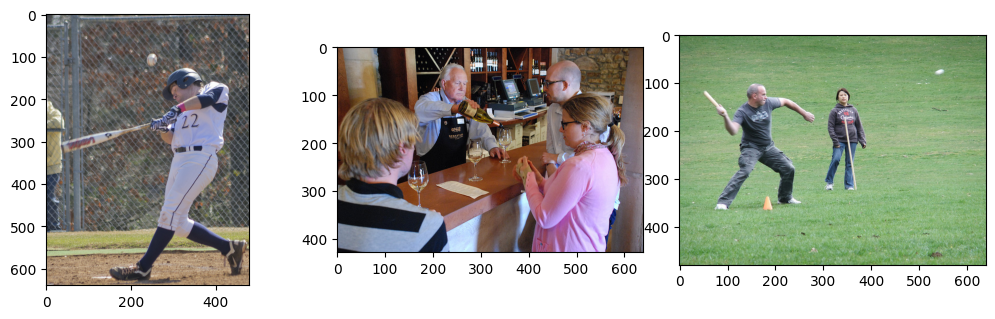

In [5]:
data_dirpath='D:/data/ultralytics/coco-pose/images/test2017'
img_files=['000000000016.jpg','000000000069.jpg','000000000063.jpg']
orig_imgs=[imread(os.path.join(data_dirpath, img_file)) for img_file in img_files if os.path.isfile(os.path.join(data_dirpath, img_file))] # HxWxC
print('images ', [im.shape for im in orig_imgs])
_, ax=plt.subplots(1,len(orig_imgs),figsize=(10,3))
for i, im in enumerate(orig_imgs): ax[i].imshow(im[...,::-1]) # BGR to RGB
plt.tight_layout(pad=0, w_pad=0, h_pad=0)

#### Preprocessing

same_shape  False
imgs_  [(640, 640, 3), (640, 640, 3), (640, 640, 3)]
imgs  torch.Size([3, 3, 640, 640])


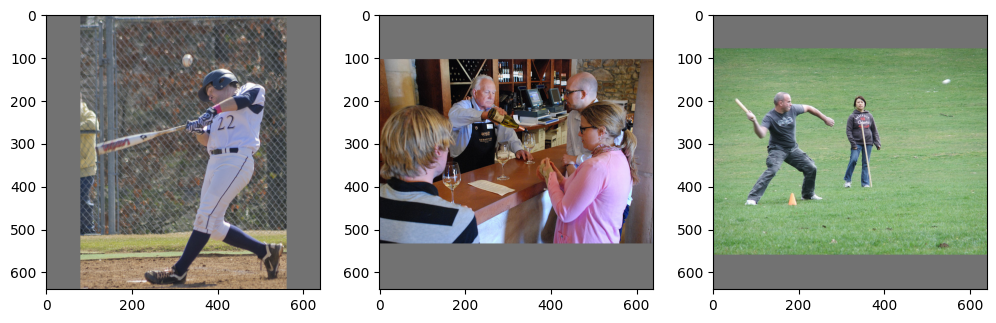

In [6]:
same_shape=len({x.shape for x in orig_imgs})==1
print('same_shape ', same_shape)

letterbox=LetterBox((640,640), auto=same_shape, stride=(8,16,32)) # stride is model strides
imgs_=[letterbox(image=x) for x in orig_imgs]
print('imgs_ ', [i.shape for i in imgs_])

# let's look at the image
_, ax=plt.subplots(1,len(imgs_),figsize=(10,3))
for i, im in enumerate(imgs_): ax[i].imshow(im[...,::-1]) # BGR to RGB
plt.tight_layout(pad=0, w_pad=0, h_pad=0)

# stack them to form batched image and normalized them
imgs=np.stack(imgs_) # BGR BxHxWxC
imgs=imgs[...,::-1] # BGR to RGB
imgs=np.ascontiguousarray( imgs.transpose((0,3,1,2)) ) # BxHxWxC to BxCxHxW
imgs=torch.from_numpy(imgs)/255. # from 0-255 to 0-1
print('imgs ', imgs.shape)

#### Inference

In [7]:
model.eval()
with torch.no_grad(): preds=model(imgs)
print('preds ', type(preds), len(preds), [type(p) for p in preds], [p.shape if isinstance(p, torch.Tensor) else len(p) for p in preds])

preds  <class 'tuple'> 2 [<class 'torch.Tensor'>, <class 'tuple'>] [torch.Size([3, 56, 8400]), 2]


#### Post processing

In [8]:
print(f'conf {predictor.args.conf}, iou {predictor.args.iou}, classes {predictor.args.classes}, agnostic_nms {predictor.args.agnostic_nms}, max_det {predictor.args.max_det}')
pred_outs=non_max_suppression(preds, conf_thres=predictor.args.conf, iou_thres=predictor.args.iou, classes=predictor.args.classes, 
                              agnostic=predictor.args.agnostic_nms, multi_label=False, max_det=predictor.args.max_det, 
                              nc=0 if predictor.args.task == "detect" else len(model.names), max_nms=30000, max_wh=7680, end2end= False, 
                              return_idxs= False)
print('pred_outs ', [p.shape for p in pred_outs])

conf 0.25, iou 0.7, classes None, agnostic_nms False, max_det 300
pred_outs  [torch.Size([2, 57]), torch.Size([4, 57]), torch.Size([2, 57])]


In [15]:
for pred, orig_img in zip(pred_outs, orig_imgs):
    pred[:,:4]=scale_boxes(imgs.shape[2:], copy.deepcopy(pred[:,:4]), orig_img.shape[:-1])
    break

In [18]:
from computer_vision.yolov11_pose.utils.ops import xyxy2xywh

((640, 480), torch.Size([640, 640]))